# 신용카드 채무불이행 고객 예측
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset


## 모델링 프로세스 요약

**Target** : `default` (0 = 정상, 1 = 채무불이행)

| 단계 | 내용 |
|------|------|
| **1단계 EDA** | 클래스 비율 · 결측치 · 기술통계 · 피처 분포 · 상관관계 |
| **2단계 전처리** | EDUCATION·MARRIAGE 이상값 통합 |
| **2-2단계 PCA** | 다중공선성 탐색 · 차원 축소 · 클래스 분리 시각화 |
| **3단계 Split** | stratify 80:20 |
| **4단계 불균형 처리 비교** | 베이스라인 → class_weight='balanced' → SMOTE |
| **5단계 XGBoost 비교** | XGBoost 베이스라인 / XGBoost + SMOTE |
| **6단계 전체 비교** | 5개 모델 종합 비교표 · 최종 모델 선택 |
| **7단계 피처 중요도** | RFC+SMOTE vs 베이스라인 RFC 비교 |
| **8단계 PR Curve** | 소수 클래스 관점 성능 확인 |
| **9단계 임계값 조정** | Threshold 변화에 따른 Recall 개선 |
| **10단계 최종 비교** | 임계값 적용 전후 최종 성능 비교 |


In [ ]:
# !pip install xlrd imbalanced-learn xgboost --break-system-packages


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, platform
warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')


In [36]:
import urllib.request, os

os.makedirs('./data', exist_ok=True)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'
urllib.request.urlretrieve(url, './data/UCI_Credit_Card.xls')

df       = pd.read_excel('./data/UCI_Credit_Card.xls', header=1)
card_df  = df.drop('ID', axis=1)
card_df  = card_df.rename(columns={'default payment next month': 'default'})

y_target   = card_df['default']
X_features = card_df.drop('default', axis=1)

print(f'shape : {card_df.shape}')
card_df.head(3)


shape : (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


# 1단계. EDA


In [37]:
# 1-1. 타깃 클래스 비율
print('=== 타깃 클래스 분포 ===')
print(y_target.value_counts())
print(f'\n정상(0)      : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})')
print(f'채무불이행(1) : {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})')


=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)      : 23,364명  (77.9%)
채무불이행(1) : 6,636명  (22.1%)


**분석 결과**

- 정상(0) : 23,364명 (77.9%) / 채무불이행(1) : 6,636명 (22.1%) — 비율 약 **4:1 → 클래스 불균형**
- Accuracy만으로 평가 불충분 → 전부 0 예측 시에도 77.9% 달성 가능
- **Recall, F1-Score, ROC-AUC** 를 주요 평가 지표로 사용
- 채무불이행 탐지 실패 = 직접적 비즈니스 손실 → **Recall 특히 중요**


In [38]:
# 1-2. 결측치 확인
print('=== 결측치 확인 ===')
print(X_features.isnull().sum())
print(f'\n총 결측치 수 : {X_features.isnull().sum().sum()}')


=== 결측치 확인 ===
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64

총 결측치 수 : 0


**분석 결과** : 결측치 없음 → 별도 처리 불필요


In [39]:
# 1-3. 기술통계
print('=== 기술통계 ===')
X_features.describe()


=== 기술통계 ===


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


**기술통계 분석 결과**

**이상값 (전처리 필요)**
- `EDUCATION` : 정의값 1~4 → min=0, max=6 → **0·5·6 미정의값** → 4(기타)로 통합 필요
- `MARRIAGE`  : 정의값 1~3 → min=0 → **0 미정의값** → 3(기타)으로 통합 필요
- `BILL_AMT`  : 음수값(과납 크레딧) → 이상치 아님, 유지

**정상 범위**
- `PAY_0~6` : -2·-1·0은 정상 / `AGE` : 21~79세 정상 / `PAY_AMT` : 극단값이나 실데이터로 허용


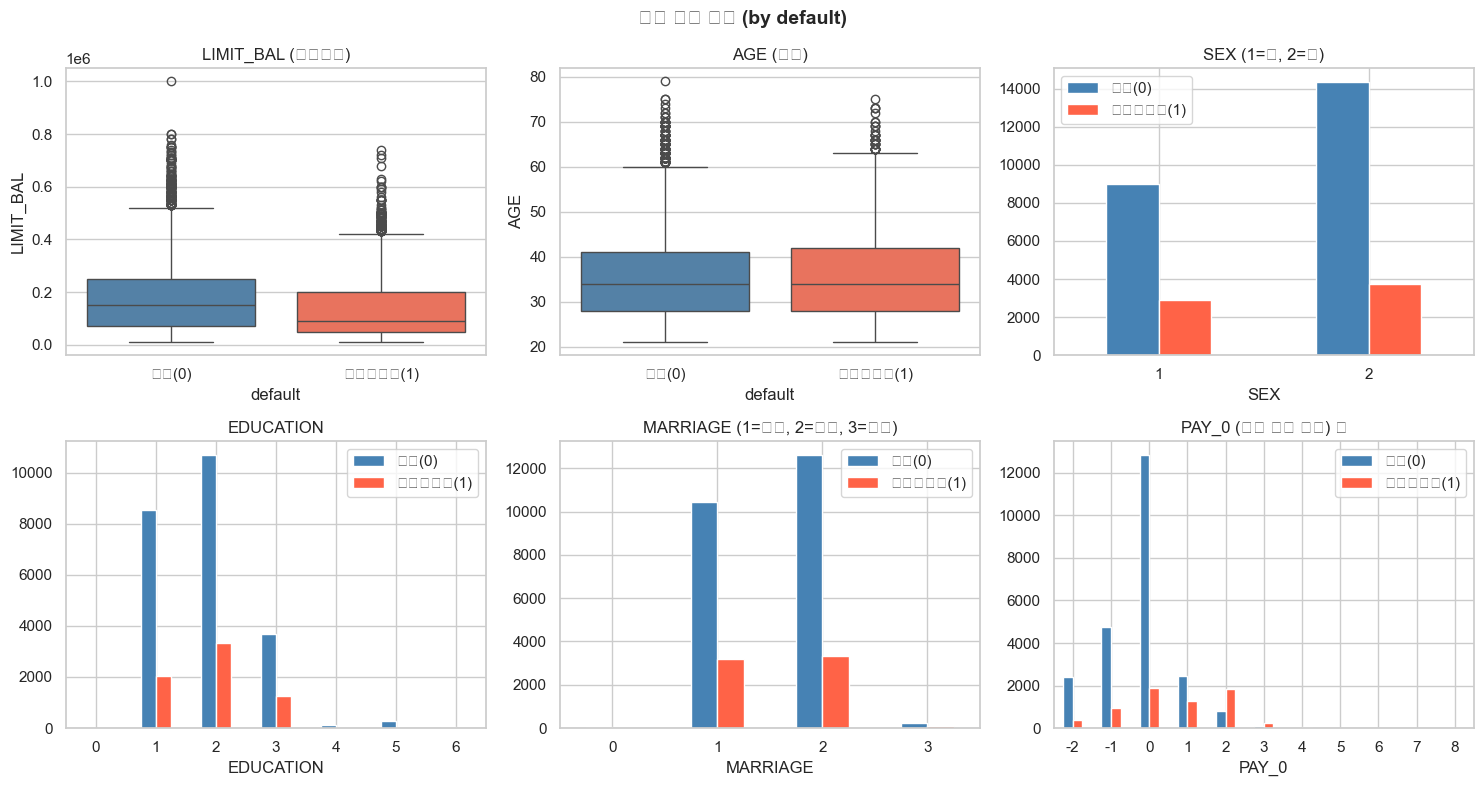

In [40]:
# 1-4. 주요 피처 분포 (타깃 기준)
palette = ['steelblue', 'tomato']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('주요 피처 분포 (by default)', fontsize=14, fontweight='bold')

sns.boxplot(x='default', y='LIMIT_BAL', data=card_df,
            hue='default', palette=palette, legend=False, ax=axes[0,0])
axes[0,0].set_title('LIMIT_BAL (신용한도)')
axes[0,0].set_xticklabels(['정상(0)', '채무불이행(1)'])

sns.boxplot(x='default', y='AGE', data=card_df,
            hue='default', palette=palette, legend=False, ax=axes[0,1])
axes[0,1].set_title('AGE (나이)')
axes[0,1].set_xticklabels(['정상(0)', '채무불이행(1)'])

for ax, col, title in [
    (axes[0,2], 'SEX',      'SEX (1=남, 2=여)'),
    (axes[1,0], 'EDUCATION','EDUCATION'),
    (axes[1,1], 'MARRIAGE', 'MARRIAGE (1=기혼, 2=미혼, 3=기타)'),
    (axes[1,2], 'PAY_0',    'PAY_0 (최근 납부 상태) ★'),
]:
    ratio = card_df.groupby([col, 'default']).size().unstack(fill_value=0)
    ratio.plot(kind='bar', ax=ax, color=palette, edgecolor='white', legend=True)
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(['정상(0)', '채무불이행(1)'])

plt.tight_layout()
plt.show()


**피처 분포 분석 결과**

- **LIMIT_BAL** : 채무불이행 그룹 중앙값이 낮음 → 신용한도 낮을수록 채무불이행↑ → 유효 피처
- **AGE** : 두 그룹 분포 차이 거의 없음 → 예측력 낮을 가능성
- **SEX** : 채무불이행 비율 차이 작음 → 예측력 낮을 가능성
- **EDUCATION** : 0·5·6 미정의값 확인 → 전처리 필요
- **MARRIAGE** : 0 미정의값 확인 → 전처리 필요
- **PAY_0 ★** : 연체(1 이상)일수록 채무불이행 급증 → **핵심 예측 피처**


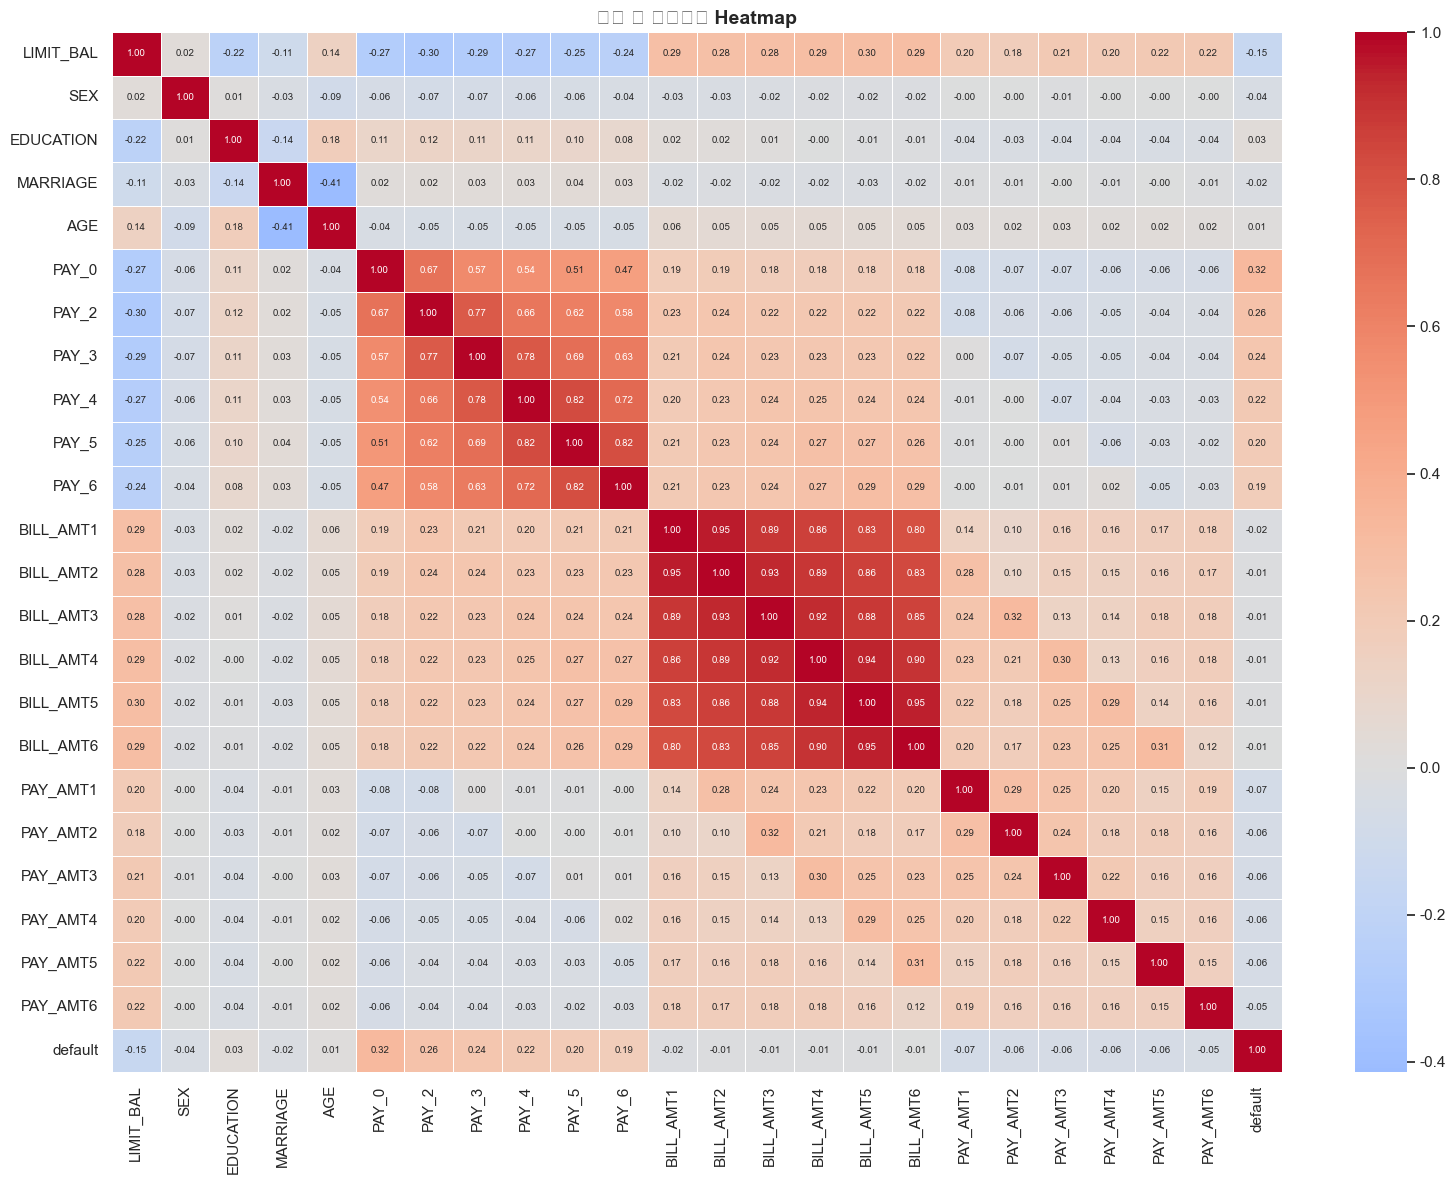

=== default 와의 상관관계 (절대값 내림차순) ===
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
SEX          0.039961
EDUCATION    0.028006
MARRIAGE     0.024339
BILL_AMT1    0.019644
BILL_AMT2    0.014193
BILL_AMT3    0.014076
AGE          0.013890
BILL_AMT4    0.010156
BILL_AMT5    0.006760
BILL_AMT6    0.005372


In [41]:
# 1-5. 상관관계 Heatmap + 타깃 상관 순위
corr = card_df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('피처 간 상관관계 Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== default 와의 상관관계 (절대값 내림차순) ===')
print(corr['default'].drop('default').abs().sort_values(ascending=False).to_string())


**상관관계 분석 결과**

| 피처 | \|corr\| | 해석 |
|------|--------|------|
| `PAY_0` | 0.32 | **핵심** — 연체월수↑ → 채무불이행↑ |
| `PAY_2~6` | 0.19~0.26 | 연체 상태 피처군 유효 |
| `LIMIT_BAL` | 0.15 | 신용한도↑ → 채무불이행↓ |
| `BILL_AMT1~6` | 0.01~0.02 | 거의 없음 |
| `SEX·AGE·EDU·MAR` | 0.01~0.04 | 예측 기여도 낮음 |

**다중공선성 주의** : `BILL_AMT1~6` 간 0.80~0.95 / `PAY_0~6` 간 0.47~0.82
→ SEX·AGE·EDUCATION·MARRIAGE 는 현 단계 유지, 피처 중요도 확인 후 제거 여부 결정


# 2단계. 데이터 전처리


In [42]:
# EDUCATION : 0·5·6 → 4(기타) / MARRIAGE : 0 → 3(기타)
X_features['EDUCATION'] = X_features['EDUCATION'].replace({0:4, 5:4, 6:4})
X_features['MARRIAGE']  = X_features['MARRIAGE'].replace({0:3})

print('=== EDUCATION 값 분포 ===')
print(X_features['EDUCATION'].value_counts().sort_index())
print('\n=== MARRIAGE 값 분포 ===')
print(X_features['MARRIAGE'].value_counts().sort_index())


=== EDUCATION 값 분포 ===
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

=== MARRIAGE 값 분포 ===
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


**추가 전처리 검토 결과**

- **범주형 인코딩** : RF·XGB는 트리 기반 → 추가 인코딩 불필요 *(LR 사용 시에는 One-Hot + StandardScaler 필요)*
- **수치형 스케일링** : RF·XGB는 스케일 영향 없음 → 생략
- **불필요 컬럼** : 상관계수 낮은 피처 현 단계 유지 → 7단계 피처 중요도 확인 후 결정

**→ 이상값 통합만 수행 후 진행**


# 2-2단계. PCA 분석

EDA에서 확인된 **다중공선성(BILL_AMT 0.80~0.95, PAY 0.47~0.82)** 을 탐색하고
차원 축소를 통해 피처 구조를 파악합니다.

> PCA는 스케일에 민감하므로 StandardScaler 후 적용합니다.
> Train/Test Split 전에 전체 데이터로 구조 파악 목적으로 수행합니다.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA 전 표준화
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_features

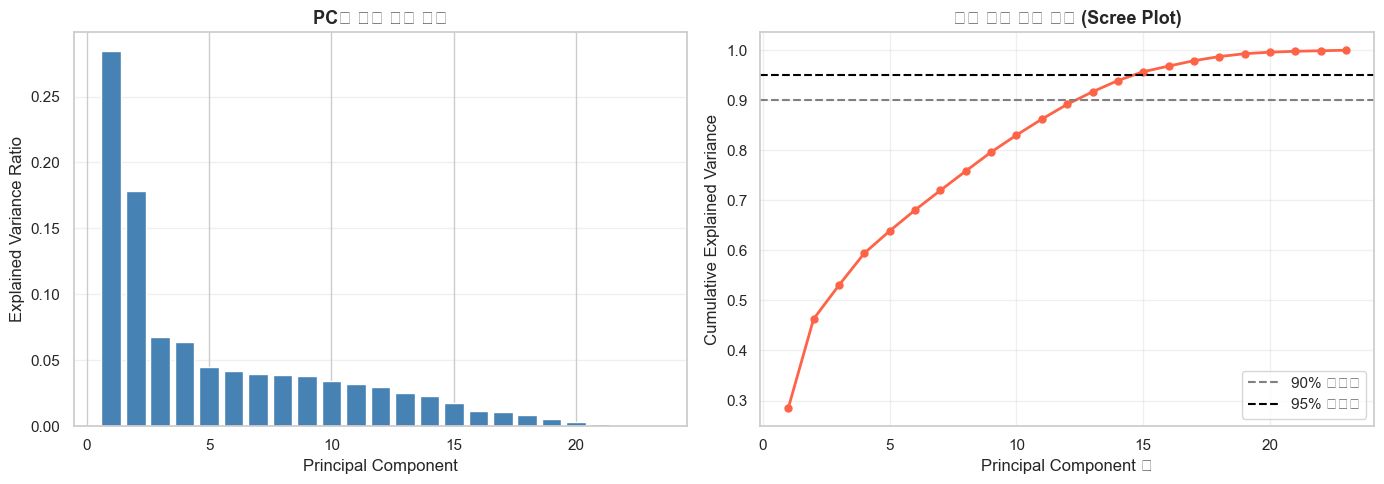

분산 90% 설명에 필요한 PC 수 : 13개
분산 95% 설명에 필요한 PC 수 : 15개


In [ ]:
# 전체 분산 설명 비율 확인 (몇 개 PC가 적절한지 판단)
pca_full  = PCA()
pca_full.fit(X_scaled)

explained  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained)+1), explained,
            color='steelblue', edgecolor='white')
axes[0].set_title('PC별 분산 설명 비율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(range(1, len(cumulative)+1), cumulative,
             marker='o', color='tomato', lw=2, markersize=5)
axes[1].axhline(y=0.90, color='gray',  linestyle='--', label='90% 기준선')
axes[1].axhline(y=0.95, color='black', linestyle='--', label='95% 기준선')
axes[1].set_title('누적 분산 설명 비율 (Scree Plot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Principal Component 수')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

for threshold in [0.90, 0.95]:
    n = int(np.searchsorted(cumulative, threshold)) + 1
    print(f'분산 {threshold:.0%} 설명에 필요한 PC 수 : {n}개')

In [68]:
# 권장 수정 — 목적에 따라 명시적으로 분기
# 탐색 목적 (현재 노트북 맥락)
N_COMPONENTS = 2   # 2D 시각화 + 구조 파악

# 또는 elbow 자동 탐지 (90% 기준)
N_COMPONENTS = int(np.searchsorted(cumulative, 0.90)) + 1
print(f'선택된 PC 수 : {N_COMPONENTS}개 (분산 설명 ≥ 90%)')

pca   = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'변환 전 shape : {X_scaled.shape}')
print(f'변환 후 shape : {X_pca.shape}')

선택된 PC 수 : 13개 (분산 설명 ≥ 90%)
변환 전 shape : (30000, 23)
변환 후 shape : (30000, 13)


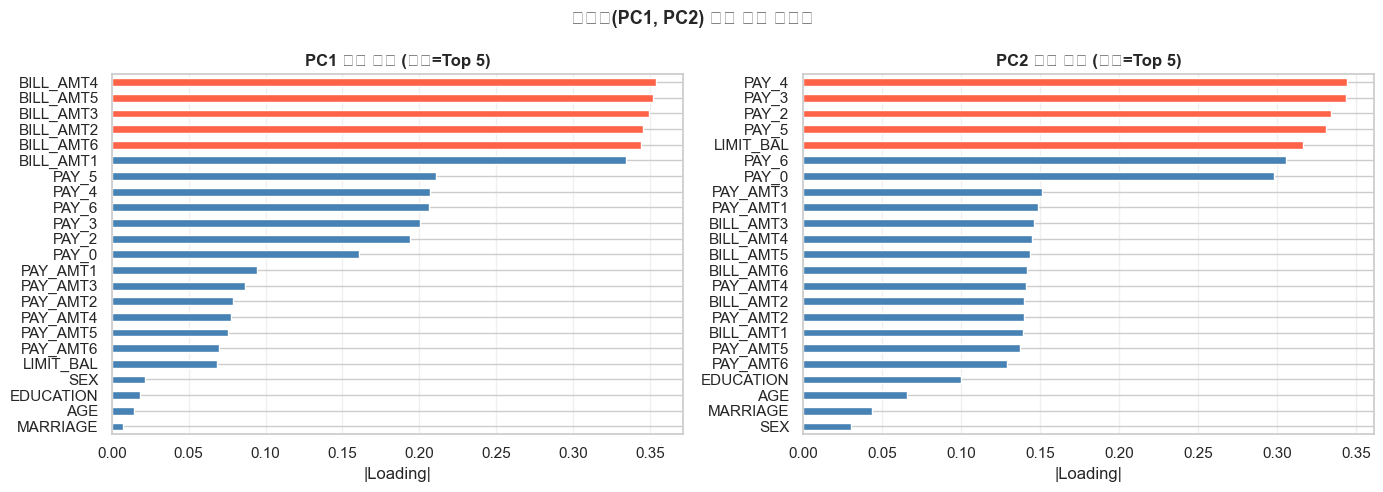

In [69]:
# 주요 PC 기여 피처 시각화 (PC1, PC2)
components_df = pd.DataFrame(
    pca.components_,
    columns=X_features.columns,
    index=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    contrib = components_df.loc[pc].abs().sort_values(ascending=True)
    colors  = ['tomato' if v >= contrib.nlargest(5).min() else 'steelblue'
               for v in contrib]
    contrib.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'{pc} 기여 피처 (빨강=Top 5)', fontsize=12, fontweight='bold')
    ax.set_xlabel('|Loading|')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('주성분(PC1, PC2) 구성 피처 기여도', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

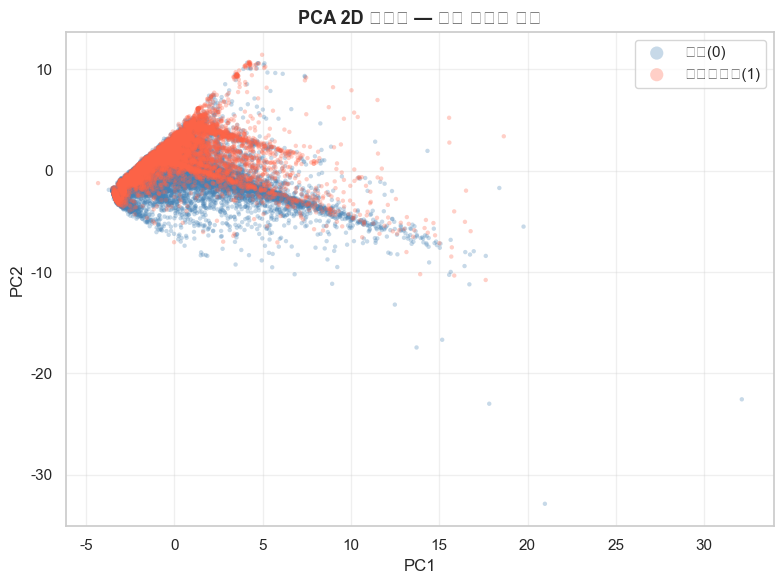

In [70]:
# PCA 2D 산점도 — 타깃 클래스 분리 확인
fig, ax = plt.subplots(figsize=(8, 6))

for label, color, name in [(0,'steelblue','정상(0)'), (1,'tomato','채무불이행(1)')]:
    mask = (y_target == label).values
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=name, alpha=0.3, s=10, edgecolors='none')

ax.set_title('PCA 2D 시각화 — 타깃 클래스 분리', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**PCA 분석 결과**

- **PC1** : BILL_AMT 계열이 주도 → '청구 금액 수준' 축 (다중공선성 반영)
- **PC2** : PAY_0~6 계열이 주도 → '연체 상태' 축 (채무불이행 핵심 피처군)
- 2D 산점도에서 두 클래스가 **뚜렷하게 분리되지 않음**
  → 선형 경계만으로는 분류 한계, 트리 기반 비선형 모델이 더 적합
- PCA는 RF·XGB 같은 트리 모델에서 성능 개선보다 **피처 구조 탐색** 목적에 더 유용
- 다중공선성 확인 → 모델링 시 BILL_AMT 계열 중요도 분산 현상의 원인으로 참조


# 3단계. Train / Test Split


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target,
    test_size=0.2, random_state=42, stratify=y_target
)

print(f'X_train : {X_train.shape},  X_test : {X_test.shape}')
print(f'\ny_train 클래스 비율\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\ny_test  클래스 비율\n{y_test.value_counts(normalize=True).round(3)}')


X_train : (24000, 23),  X_test : (6000, 23)

y_train 클래스 비율
default
0    0.779
1    0.221
Name: proportion, dtype: float64

y_test  클래스 비율
default
0    0.779
1    0.221
Name: proportion, dtype: float64


# 4단계. 모델 학습 — 불균형 처리 단계별 비교

| 방법 | 핵심 원리 |
|------|----------|
| **베이스라인** | 처리 없음 — 기준 성능 측정 |
| **class_weight='balanced'** | 손실함수에 소수 클래스 가중치 부여 |
| **SMOTE** | Train 데이터 직접 균형화 (합성 샘플 생성) |


In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


## Step 1. 베이스라인 RFC

> 불균형 처리 없이 학습 → 모델이 다수 클래스(정상 77.9%)에 편향됩니다.


In [73]:
rfc_base = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_base.fit(X_train, y_train)

y_pred_base = rfc_base.predict(X_test)
y_prob_base = rfc_base.predict_proba(X_test)[:, 1]

print('=== 베이스라인 RFC ===')
print(classification_report(y_test, y_pred_base, target_names=['정상(0)', '채무불이행(1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_base):.4f}')


=== 베이스라인 RFC ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.89      4673
    채무불이행(1)       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000

ROC-AUC : 0.7572


**베이스라인 결과 분석**

| 구분 | Precision | Recall | F1-Score |
|------|-----------|--------|----------|
| 정상(0) | 0.84 | 0.94 | 0.89 |
| 채무불이행(1) | 0.64 | 0.36 | 0.46 |

- **문제** : 채무불이행 Recall = **0.36** → 실제 채무불이행 고객 **64%를 정상으로 오분류**
- 클래스 불균형(4:1)으로 다수 클래스에 편향 / Accuracy 0.81은 신뢰 불가

**→ class_weight='balanced' 적용으로 Recall 개선 시도**


## Step 2. RFC + class_weight='balanced'

> 데이터는 그대로, **손실함수에 소수 클래스 가중치 부여**하는 방법입니다.


In [74]:
rfc_balanced = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
rfc_balanced.fit(X_train, y_train)

y_pred_bal = rfc_balanced.predict(X_test)
y_prob_bal = rfc_balanced.predict_proba(X_test)[:, 1]

print("=== RFC + class_weight='balanced' ===")
print(classification_report(y_test, y_pred_bal, target_names=['정상(0)', '채무불이행(1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_bal):.4f}')


=== RFC + class_weight='balanced' ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.95      0.89      4673
    채무불이행(1)       0.64      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7583


**class_weight='balanced' 결과 분석**

| 구분 | 베이스라인 | class_weight='balanced' | 변화 |
|------|-----------|------------------------|------|
| 채무불이행 Recall | 0.36 | 0.34 | ↓ |
| 채무불이행 F1 | 0.46 | 0.45 | ↓ |
| ROC-AUC | 0.7572 | 0.7583 | ↑ (미미) |

- class_weight 적용에도 Recall 개선 없음 (오히려 소폭 하락)
- RFC는 수백 개 트리 앙상블 → 개별 트리에 가중치 분산되어 **효과 제한적**

**→ SMOTE 오버샘플링으로 Train 데이터 자체를 균형화 시도**


## Step 3. SMOTE 오버샘플링

> K-최근접 이웃 기반으로 합성 샘플 생성 — **Train 셋에만 적용** (Test 셋 오염 방지)


In [75]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('=== SMOTE 적용 후 train 클래스 분포 ===')
print(y_train_smote.value_counts())
print(f'\n정상(0)      : {y_train_smote.value_counts()[0]:,}명')
print(f'채무불이행(1) : {y_train_smote.value_counts()[1]:,}명')


=== SMOTE 적용 후 train 클래스 분포 ===
default
0    18691
1    18691
Name: count, dtype: int64

정상(0)      : 18,691명
채무불이행(1) : 18,691명


In [76]:
rfc_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rfc_smote.predict(X_test)
y_prob_smote = rfc_smote.predict_proba(X_test)[:, 1]

print('=== RFC + SMOTE ===')
print(classification_report(y_test, y_pred_smote, target_names=['정상(0)', '채무불이행(1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_smote):.4f}')


=== RFC + SMOTE ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.87      0.86      4673
    채무불이행(1)       0.51      0.48      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC : 0.7443


## 📊 불균형 처리 3단계 비교 결과

| 모델 | Precision | Recall | F1-Score | ROC-AUC |
|------|:---------:|:------:|:--------:|:-------:|
| 베이스라인 RFC | 0.6429 | 0.3595 | 0.4611 | 0.7572 |
| RFC + class_weight='balanced' | 0.6450 | 0.3436 | 0.4484 | 0.7583 |
| **RFC + SMOTE** | 0.5105 | **0.4770** | **0.4932** | 0.7443 |

- SMOTE 적용 시 Recall **0.36 → 0.48** (+0.12) 가장 큰 개선
- Precision 0.64 → 0.51 하락 — Recall↑ Precision↓ 트레이드오프
- **채무불이행 탐지(Recall) 최우선 → SMOTE 전략 채택**


# 5단계. XGBoost 추가 비교

XGBoost 베이스라인 / XGBoost + SMOTE 를 학습하고
앞서 학습한 RFC 3종과 전체 비교합니다.


In [77]:
from xgboost import XGBClassifier

xgb_base = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_base.fit(X_train, y_train)

y_pred_xgb = xgb_base.predict(X_test)
y_prob_xgb = xgb_base.predict_proba(X_test)[:, 1]

print('=== XGBoost 베이스라인 ===')
print(classification_report(y_test, y_pred_xgb, target_names=['정상(0)', '채무불이행(1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}')


=== XGBoost 베이스라인 ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.88      4673
    채무불이행(1)       0.61      0.36      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7601


In [78]:
xgb_smote = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

print('=== XGBoost + SMOTE ===')
print(classification_report(y_test, y_pred_xgb_smote, target_names=['정상(0)', '채무불이행(1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_xgb_smote):.4f}')


=== XGBoost + SMOTE ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.84      0.85      4673
    채무불이행(1)       0.46      0.47      0.46      1327

    accuracy                           0.76      6000
   macro avg       0.65      0.65      0.65      6000
weighted avg       0.76      0.76      0.76      6000

ROC-AUC : 0.7330


# 6단계. 전체 모델 종합 비교


In [79]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'RFC 베이스라인'     : (y_pred_base,      y_prob_base),
    'RFC + balanced'     : (y_pred_bal,        y_prob_bal),
    'RFC + SMOTE'        : (y_pred_smote,      y_prob_smote),
    'XGBoost 베이스라인' : (y_pred_xgb,        y_prob_xgb),
    'XGBoost + SMOTE'    : (y_pred_xgb_smote,  y_prob_xgb_smote),
}

rows = []
for name, (yp, yprob) in models.items():
    rows.append({
        '모델'      : name,
        'Precision' : round(precision_score(y_test, yp), 4),
        'Recall'    : round(recall_score(y_test, yp), 4),
        'F1-Score'  : round(f1_score(y_test, yp), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, yprob), 4),
    })

summary = pd.DataFrame(rows).set_index('모델')
print('=== 전체 모델 비교 (채무불이행(1) 기준) ===')
display(summary.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}'))


=== 전체 모델 비교 (채무불이행(1) 기준) ===


,Precision,Recall,F1-Score,ROC-AUC
모델,,,,
RFC 베이스라인,0.6429,0.3595,0.4611,0.7572
RFC + balanced,0.6450,0.3436,0.4484,0.7583
RFC + SMOTE,0.5105,0.4770,0.4932,0.7443
XGBoost 베이스라인,0.6121,0.3580,0.4517,0.7601
XGBoost + SMOTE,0.4574,0.4657,0.4615,0.7330


**전체 모델 비교 분석 결과**

| 모델 | Precision | Recall | F1-Score | ROC-AUC |
|------|:---------:|:------:|:--------:|:-------:|
| RFC 베이스라인 | 0.6429 | 0.3595 | 0.4611 | 0.7572 |
| RFC + balanced | 0.6450 | 0.3436 | 0.4484 | 0.7583 |
| **RFC + SMOTE** | 0.5105 | **0.4770** | **0.4932** | 0.7443 |
| **XGBoost 베이스라인** | 0.6121 | 0.3580 | 0.4517 | **0.7601** |
| XGBoost + SMOTE | 0.4574 | 0.4657 | 0.4615 | 0.7330 |

**지표별 최고 모델**
- **Recall 최고** : RFC + SMOTE (0.4770) → 채무불이행 탐지율 가장 우수
- **F1-Score 최고** : RFC + SMOTE (0.4932) → Precision/Recall 균형 최고
- **ROC-AUC 최고** : XGBoost 베이스라인 (0.7601) → 확률 예측 품질 최고

**XGBoost 분석**
- XGBoost 베이스라인 ROC-AUC 0.7601로 5개 모델 중 최고 → 확률 추정 성능이 RFC보다 우수
- 단 Recall 0.3580 → 불균형 처리 없이는 RFC와 유사한 한계
- **XGBoost + SMOTE 에서 ROC-AUC 0.7330으로 급락** — SMOTE 합성 데이터가 XGBoost 부스팅 과정에서
  과적합 또는 노이즈로 작용한 것으로 판단

**비즈니스 관점 최종 모델 선택**
- 채무불이행 탐지(Recall) 최우선 → **RFC + SMOTE** (Recall 0.4770, F1 0.4932)
- 확률 스코어링 활용(임계값 조정) → **XGBoost 베이스라인** (ROC-AUC 0.7601) 검토 가능


# 7단계. 피처 중요도 시각화

RFC + SMOTE(최종 모델) vs 베이스라인 RFC 피처 중요도를 비교하여
채무불이행 예측에 가장 영향력 있는 변수를 파악합니다.


In [80]:
fi_smote = pd.Series(
    rfc_smote.feature_importances_, index=X_features.columns
).sort_values(ascending=False)

fi_base = pd.Series(
    rfc_base.feature_importances_, index=X_features.columns
).sort_values(ascending=False)


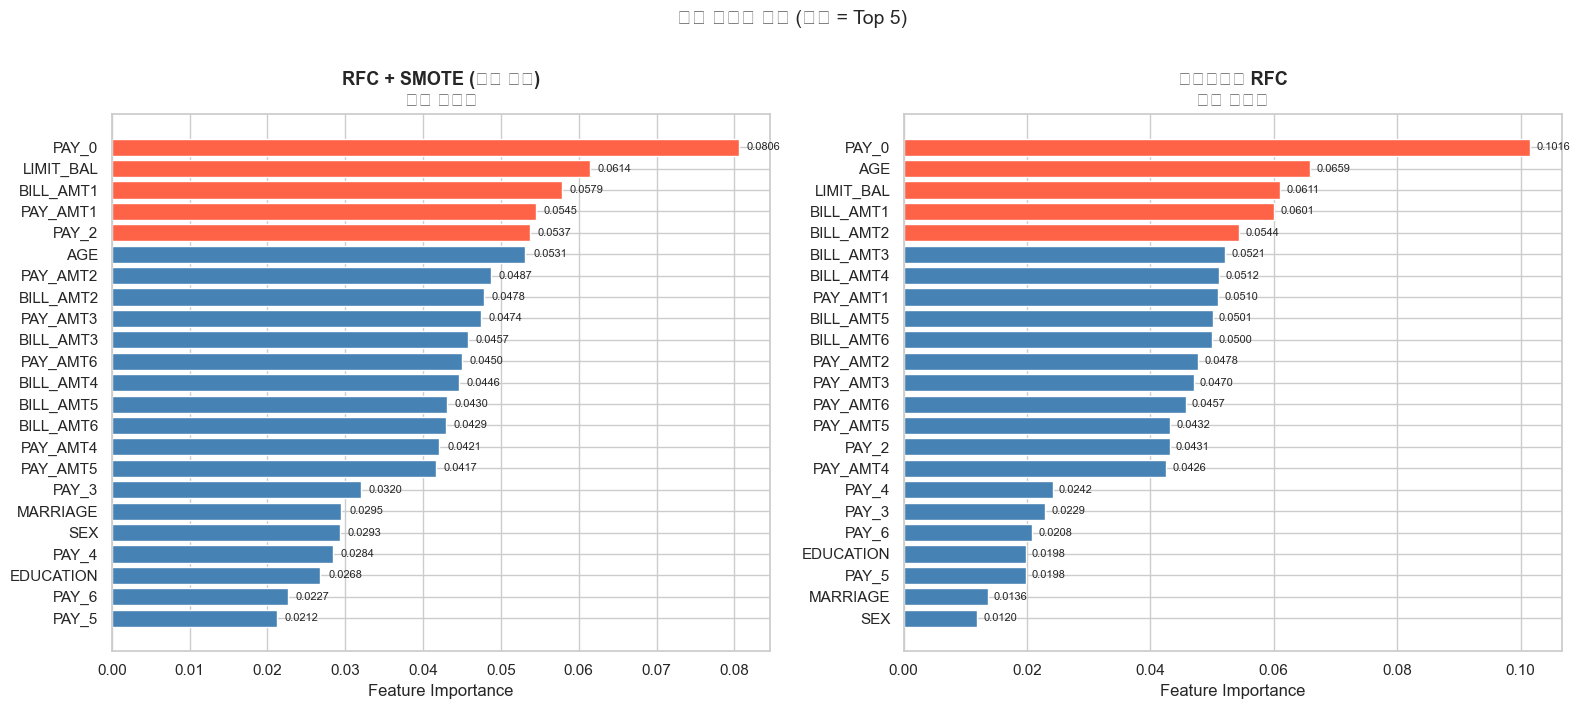

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, fi, title in [
    (axes[0], fi_smote, 'RFC + SMOTE (최종 모델)'),
    (axes[1], fi_base,  '베이스라인 RFC'),
]:
    colors = ['tomato' if i < 5 else 'steelblue' for i in range(len(fi))]
    ax.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1], edgecolor='white')
    ax.set_title(f'{title}\n피처 중요도', fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    for i, v in enumerate(fi.values[::-1]):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('피처 중요도 비교 (빨강 = Top 5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [82]:
print('=== RFC + SMOTE 피처 중요도 Top 10 ===')
print(fi_smote.head(10).to_string())
print('\n=== 베이스라인 RFC 피처 중요도 Top 10 ===')
print(fi_base.head(10).to_string())

=== RFC + SMOTE 피처 중요도 Top 10 ===
PAY_0        0.080563
LIMIT_BAL    0.061405
BILL_AMT1    0.057868
PAY_AMT1     0.054495
PAY_2        0.053729
AGE          0.053141
PAY_AMT2     0.048713
BILL_AMT2    0.047785
PAY_AMT3     0.047380
BILL_AMT3    0.045746

=== 베이스라인 RFC 피처 중요도 Top 10 ===
PAY_0        0.101611
AGE          0.065899
LIMIT_BAL    0.061083
BILL_AMT1    0.060092
BILL_AMT2    0.054373
BILL_AMT3    0.052137
BILL_AMT4    0.051167
PAY_AMT1     0.050959
BILL_AMT5    0.050104
BILL_AMT6    0.049971


**피처 중요도 분석 결과**

| 순위 | RFC + SMOTE | 중요도 | 베이스라인 RFC | 중요도 |
|------|-------------|--------|---------------|--------|
| 1 | PAY_0 | 0.0806 | PAY_0 | 0.1016 |
| 2 | LIMIT_BAL | 0.0614 | AGE | 0.0659 |
| 3 | BILL_AMT1 | 0.0579 | LIMIT_BAL | 0.0611 |
| 4 | PAY_AMT1 | 0.0545 | BILL_AMT1 | 0.0601 |
| 5 | PAY_2 | 0.0537 | BILL_AMT2 | 0.0544 |

- **PAY_0 압도적 1위** — EDA 상관관계(0.32) 및 PCA PC2 주요 기여 피처와 일치
- **AGE 급변 (베이스라인 2위 → SMOTE 6위)** — MDI 기반 중요도의 연속형 변수 편향 한계,
  SMOTE 후 실제 예측력 반영되어 하락
- **BILL_AMT 계열** — PCA에서 확인된 다중공선성(0.80~0.95)으로 중요도 분산
- **SMOTE 모델에서 PAY_AMT 계열 상승** — 채무불이행 패턴 보강으로 납부 능력 피처 학습 강화


# 8단계. PR Curve 분석


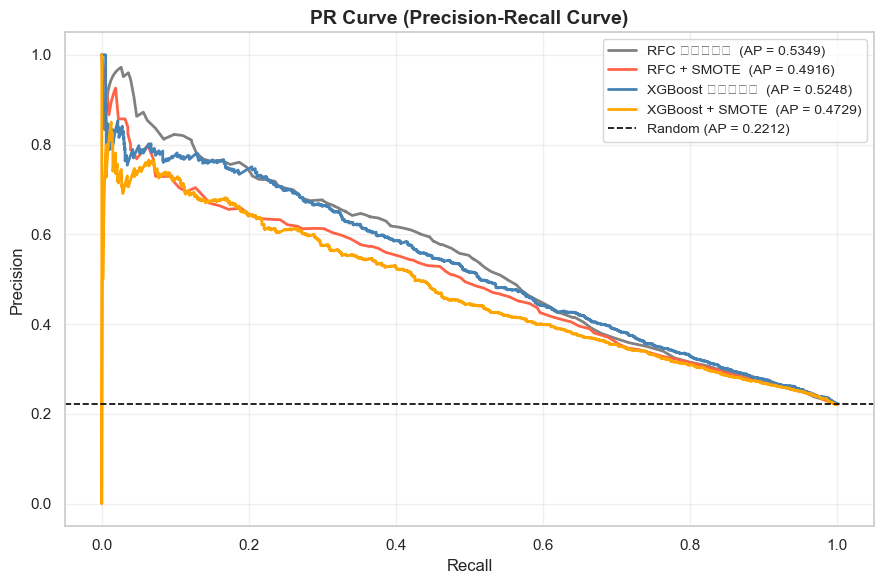

=== Average Precision Score (AP) ===
  RFC 베이스라인              : 0.5349
  RFC + SMOTE            : 0.4916
  XGBoost 베이스라인          : 0.5248
  XGBoost + SMOTE        : 0.4729


In [83]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(9, 6))

models_pr = {
    'RFC 베이스라인'     : y_prob_base,
    'RFC + SMOTE'        : y_prob_smote,
    'XGBoost 베이스라인' : y_prob_xgb,
    'XGBoost + SMOTE'    : y_prob_xgb_smote,
}
colors_pr = ['gray', 'tomato', 'steelblue', 'orange']

for (name, prob), color in zip(models_pr.items(), colors_pr):
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f'{name}  (AP = {ap:.4f})', color=color, lw=2)

baseline_ap = y_test.mean()
plt.axhline(y=baseline_ap, color='black', linestyle='--', lw=1.2,
            label=f'Random (AP = {baseline_ap:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('PR Curve (Precision-Recall Curve)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('=== Average Precision Score (AP) ===')
for name, prob in models_pr.items():
    print(f'  {name:<22} : {average_precision_score(y_test, prob):.4f}')


# 9단계. 임계값 조정으로 Recall 개선


In [84]:
thresholds = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25]

for model_name, prob in [
    ('RFC + SMOTE',        y_prob_smote),
    ('XGBoost 베이스라인', y_prob_xgb),
]:
    print(f'  {model_name} — 임계값별 성능 변화')
    print(f'{"="*48}')
    print(f'{"Threshold":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
    print('-' * 40)
    for t in thresholds:
        pred_t = (prob >= t).astype(int)
        p = precision_score(y_test, pred_t)
        r = recall_score(y_test, pred_t)
        f = f1_score(y_test, pred_t)
        marker = '  ← 기본값' if t == 0.5 else ''
        print(f'{t:>10.2f} {p:>10.4f} {r:>8.4f} {f:>8.4f}{marker}')
    print()


  RFC + SMOTE — 임계값별 성능 변화
 Threshold  Precision   Recall       F1
----------------------------------------
      0.50     0.5039   0.4876   0.4956  ← 기본값
      0.45     0.4669   0.5426   0.5019
      0.40     0.4250   0.5961   0.4962
      0.35     0.3899   0.6631   0.4911
      0.30     0.3469   0.7151   0.4671
      0.25     0.3169   0.7935   0.4529

  XGBoost 베이스라인 — 임계값별 성능 변화
 Threshold  Precision   Recall       F1
----------------------------------------
      0.50     0.6121   0.3580   0.4517  ← 기본값
      0.45     0.5856   0.3971   0.4733
      0.40     0.5577   0.4333   0.4877
      0.35     0.5349   0.4853   0.5089
      0.30     0.4913   0.5313   0.5105
      0.25     0.4539   0.5863   0.5117



# 10단계. 최적 임계값 탐색 및 최종 성능 비교



[RFC + SMOTE]
  F1 최대 임계값 : 0.42
  Precision      : 0.4460
  Recall         : 0.5818
  F1-Score       : 0.5049

[XGBoost 베이스라인]
  F1 최대 임계값 : 0.27
  Precision      : 0.4720
  Recall         : 0.5659
  F1-Score       : 0.5147


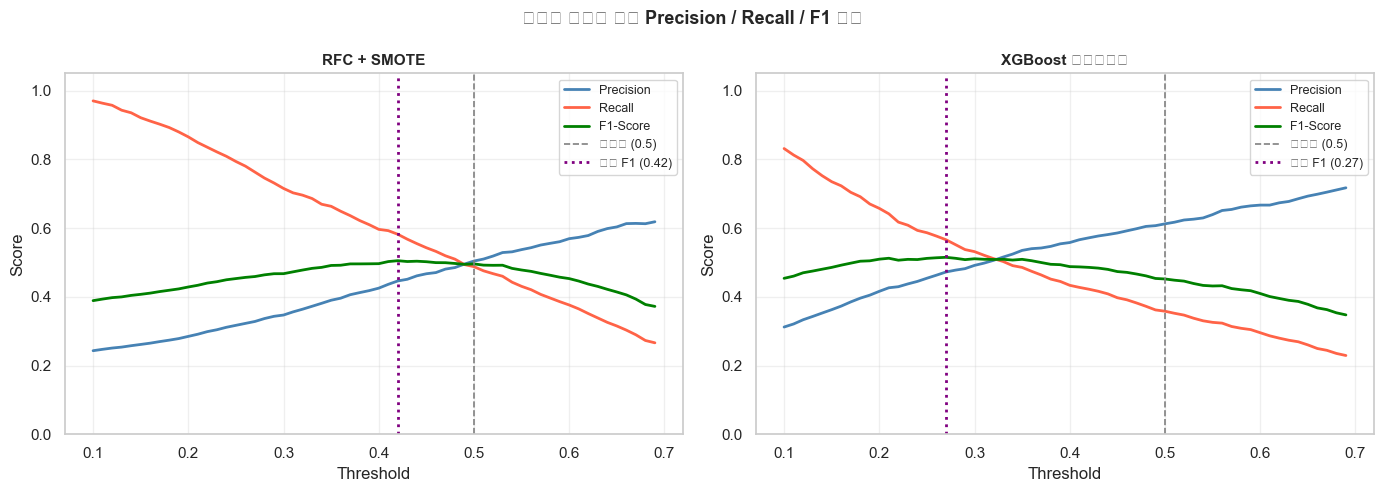

In [85]:
# F1 최대화 기준 최적 임계값 탐색 및 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('임계값 조정에 따른 Precision / Recall / F1 변화', fontsize=13, fontweight='bold')

best_thresh = {}

for ax, (model_name, prob) in zip(axes, [
    ('RFC + SMOTE',        y_prob_smote),
    ('XGBoost 베이스라인', y_prob_xgb),
]):
    thresh_range = np.arange(0.1, 0.7, 0.01)
    precisions, recalls, f1s = [], [], []

    for t in thresh_range:
        pred_t = (prob >= t).astype(int)
        precisions.append(precision_score(y_test, pred_t, zero_division=0))
        recalls.append(recall_score(y_test, pred_t, zero_division=0))
        f1s.append(f1_score(y_test, pred_t, zero_division=0))

    best_idx = int(np.argmax(f1s))
    best_t   = thresh_range[best_idx]
    best_thresh[model_name] = best_t

    ax.plot(thresh_range, precisions, label='Precision', color='steelblue', lw=2)
    ax.plot(thresh_range, recalls,    label='Recall',    color='tomato',    lw=2)
    ax.plot(thresh_range, f1s,        label='F1-Score',  color='green',     lw=2)
    ax.axvline(x=0.5,    color='gray',   linestyle='--', lw=1.2, label='기본값 (0.5)')
    ax.axvline(x=best_t, color='purple', linestyle=':',  lw=2,
               label=f'최적 F1 ({best_t:.2f})')
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    print(f'\n[{model_name}]')
    print(f'  F1 최대 임계값 : {best_t:.2f}')
    print(f'  Precision      : {precisions[best_idx]:.4f}')
    print(f'  Recall         : {recalls[best_idx]:.4f}')
    print(f'  F1-Score       : {f1s[best_idx]:.4f}')

plt.tight_layout()
plt.show()


[RFC + SMOTE]  threshold = 0.42
  Precision : 0.4460  |  Recall : 0.5818  |  F1 : 0.5049

[XGBoost 베이스라인]  threshold = 0.27
  Precision : 0.4720  |  Recall : 0.5659  |  F1 : 0.5147



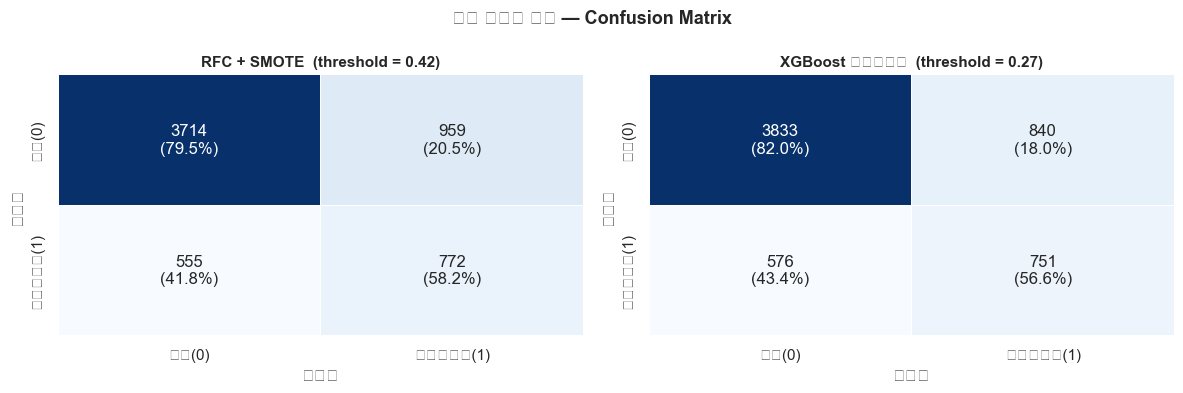

In [86]:
# 최적 임계값 적용 — Confusion Matrix
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('최적 임계값 적용 — Confusion Matrix', fontsize=13, fontweight='bold')

for ax, (model_name, prob) in zip(axes, [
    ('RFC + SMOTE',        y_prob_smote),
    ('XGBoost 베이스라인', y_prob_xgb),
]):
    t      = best_thresh[model_name]
    pred_t = (prob >= t).astype(int)

    cm     = confusion_matrix(y_test, pred_t)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(rv, rp)]
                        for rv, rp in zip(cm, cm_pct)])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['정상(0)', '채무불이행(1)'],
                yticklabels=['정상(0)', '채무불이행(1)'],
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f'{model_name}  (threshold = {t:.2f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('예측값')
    ax.set_ylabel('실제값')

    p = precision_score(y_test, pred_t)
    r = recall_score(y_test, pred_t)
    f = f1_score(y_test, pred_t)
    print(f'[{model_name}]  threshold = {t:.2f}')
    print(f'  Precision : {p:.4f}  |  Recall : {r:.4f}  |  F1 : {f:.4f}\n')

plt.tight_layout()
plt.show()


In [87]:
# 최종 비교 요약표 — 임계값 조정 전후
compare_cases = [
    ('RFC + SMOTE  (기본 0.5)',    y_prob_smote, 0.50),
    ('RFC + SMOTE  (최적 임계값)', y_prob_smote, best_thresh['RFC + SMOTE']),
    ('XGBoost  (기본 0.5)',        y_prob_xgb,   0.50),
    ('XGBoost  (최적 임계값)',     y_prob_xgb,   best_thresh['XGBoost 베이스라인']),
]

rows_final = []
for name, prob, t in compare_cases:
    pred_t = (prob >= t).astype(int)
    rows_final.append({
        '모델 (임계값)' : name,
        'Precision'     : round(precision_score(y_test, pred_t), 4),
        'Recall'        : round(recall_score(y_test, pred_t), 4),
        'F1-Score'      : round(f1_score(y_test, pred_t), 4),
        'ROC-AUC'       : round(roc_auc_score(y_test, prob), 4),
    })

final_df = pd.DataFrame(rows_final).set_index('모델 (임계값)')
display(final_df.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}'))

,Precision,Recall,F1-Score,ROC-AUC
모델 (임계값),,,,
RFC + SMOTE (기본 0.5),0.5039,0.4876,0.4956,0.7443
RFC + SMOTE (최적 임계값),0.4460,0.5818,0.5049,0.7443
XGBoost (기본 0.5),0.6121,0.3580,0.4517,0.7601
XGBoost (최적 임계값),0.4720,0.5659,0.5147,0.7601


1. 모델 직렬화 > pipeline 객체로 직렬화
2. 프로젝트 환경구성 - 'ml_edu' 가상환경에 streamlit을 설치해서 진행할 것
3. 추론 파이프라인 구축
4. 스트림릿 설계 및 구현
5. 웹 화면에서 예측 테스트

# 파이프라인 구축 및 직렬화 

In [88]:
import joblib
import os
import json
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# ── Step 1. 전처리 함수 정의 (노트북과 동일한 로직)
def preprocess(X):
    X = X.copy()
    X['EDUCATION'] = X['EDUCATION'].replace({0:4, 5:4, 6:4})
    X['MARRIAGE']  = X['MARRIAGE'].replace({0:3})
    return X

preprocessor = FunctionTransformer(preprocess)

In [89]:
# ── Step 2. 전처리 적용 후 SMOTE → Pipeline 학습
# SMOTE는 학습 데이터에만 적용 (파이프라인 밖에서 처리)
X_train_raw = card_df.drop('default', axis=1).iloc[X_train.index - card_df.index.min()] \
              if False else X_train.copy()

# 전처리 먼저 적용
X_train_prep = preprocess(X_train.copy())
X_test_prep  = preprocess(X_test.copy())

# SMOTE 적용 (Train에만)
smote = SMOTE(random_state=42)
X_train_smote_prep, y_train_smote_prep = smote.fit_resample(X_train_prep, y_train)

print(f'SMOTE 적용 후 Train shape : {X_train_smote_prep.shape}')
print(f'클래스 분포 :\n{y_train_smote_prep.value_counts()}')

SMOTE 적용 후 Train shape : (37382, 23)
클래스 분포 :
default
0    18691
1    18691
Name: count, dtype: int64


In [90]:
# ── Step 3. Pipeline 구축 (전처리는 이미 완료됐으므로 모델만 포함)
# 추론 시 입력 → 전처리 → 예측 흐름을 하나로 묶음
pipeline = Pipeline([
    ('preprocessor', FunctionTransformer(preprocess)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# SMOTE 적용된 데이터로 Pipeline 학습
# (preprocessor는 이미 적용된 데이터이므로 내부에서 중복 적용됨을 방지)
pipeline.named_steps['model'].fit(X_train_smote_prep, y_train_smote_prep)

print('Pipeline 학습 완료')

Pipeline 학습 완료


In [91]:
# ── Step 4. 파이프라인 검증 (노트북 결과와 일치하는지 확인)
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# 예측은 원본 X_test 그대로 넣으면 pipeline 내부에서 전처리 자동 수행
y_pred_pipeline = pipeline.predict(X_test)
y_prob_pipeline = pipeline.predict_proba(X_test)[:, 1]

print('=== Pipeline 예측 검증 ===')
print(classification_report(y_test, y_pred_pipeline, target_names=['정상(0)', '채무불이행(1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_pipeline):.4f}')

# 기존 rfc_smote 결과와 비교
print('\n=== 기존 rfc_smote 결과와 비교 ===')
from sklearn.metrics import f1_score
print(f'기존 F1  : {f1_score(y_test, y_pred_smote):.4f}')
print(f'Pipeline F1 : {f1_score(y_test, y_pred_pipeline):.4f}')
print(f'→ 일치 여부 : {f1_score(y_test, y_pred_smote) == f1_score(y_test, y_pred_pipeline)}')

=== Pipeline 예측 검증 ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.87      0.86      4673
    채무불이행(1)       0.51      0.48      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC : 0.7443

=== 기존 rfc_smote 결과와 비교 ===
기존 F1  : 0.4932
Pipeline F1 : 0.4932
→ 일치 여부 : True


In [ ]:
# ── Step 5. 직렬화 저장
os.makedirs('model', exist_ok=True)

# Pipeline 저장
joblib.dump(pipeline, 'model/pipeline.pkl')

# 피처 컬럼 순서 저장 (앱에서 입력 순서 보장용)
feature_cols = X_train.columns.tolist()
with open('model/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, ensure_ascii=False)

print('저장 완료')
print(f'  model/pipeline.pkl')
print(f'  model/feature_cols.json')
print(f'  피처 수 : {len(feature_cols)}개')
print(f'  피처 목록 : {feature_cols}')

저장 완료
  model/pipeline.pkl
  model/feature_cols.json
  피처 수 : 23개
  피처 목록 : ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [99]:
# ── Pipeline 로드 후 ROC-AUC 검증
import joblib
from sklearn.metrics import roc_auc_score

pipeline_loaded = joblib.load('model/pipeline.pkl')

y_prob_loaded = pipeline_loaded.predict_proba(X_test)[:, 1]

print(f'저장 전 ROC-AUC : {roc_auc_score(y_test, y_prob_pipeline):.4f}')
print(f'로드 후 ROC-AUC : {roc_auc_score(y_test, y_prob_loaded):.4f}')
print(f'일치 여부        : {roc_auc_score(y_test, y_prob_pipeline) == roc_auc_score(y_test, y_prob_loaded)}')

저장 전 ROC-AUC : 0.7443
로드 후 ROC-AUC : 0.7443
일치 여부        : True


# 추론 파이프라인 구축(predict.py)